<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Collapse002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

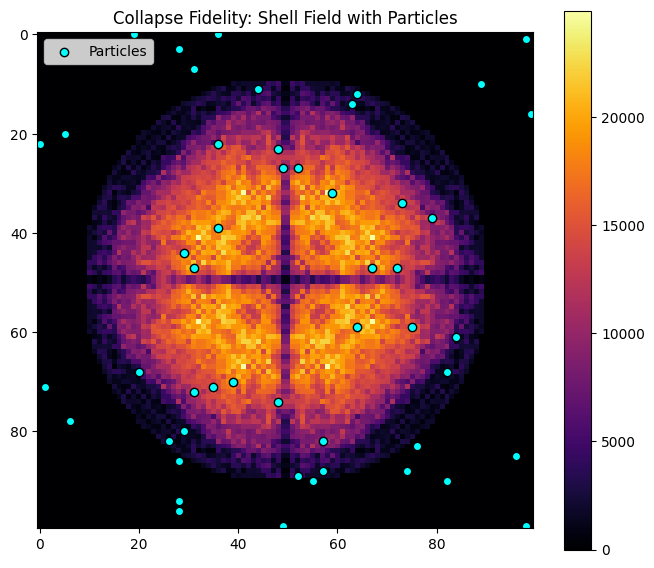

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Collapse002: Shell + Particles — Field–Particle Duality

# Parameters
N = 100
timesteps = 500
alpha = 2.0
beta = 0.1
num_particles = 50

# Shell entropy field
def shell_entropy(N):
    x = np.linspace(-1, 1, N)
    grid = np.meshgrid(x, x, x)
    r = np.sqrt(sum(g**2 for g in grid))
    return np.exp(-((r - 0.5)**2) * 20)

# Initialize particles: positions and velocities
def initialize_particles(num, N):
    positions = np.random.randint(0, N, size=(num, 3))
    velocities = np.random.randn(num, 3) * 0.5  # random motion
    return positions, velocities

# Collapse + particle update
def simulate_collapse_with_particles(entropy, alpha, beta, positions, velocities):
    collapsed = np.zeros_like(entropy)
    for t in range(timesteps):
        gradient = np.gradient(entropy)
        magnitude = np.sqrt(sum(g**2 for g in gradient))
        non_zero_mag = magnitude[magnitude > 1e-9]
        if non_zero_mag.size == 0:
            adaptive_threshold = 0.0
        else:
            mu_grad = np.mean(non_zero_mag)
            sigma_grad = np.std(non_zero_mag)
            adaptive_threshold = alpha * mu_grad + beta * sigma_grad

        collapse_mask = magnitude > adaptive_threshold
        entropy[collapse_mask] *= 0.9
        collapsed += collapse_mask.astype(float)

        # Particle update
        for i in range(len(positions)):
            pos = positions[i]
            vel = velocities[i]
            # Move particle
            new_pos = np.clip(pos + vel.astype(int), 0, N-1)
            # If particle enters collapse zone, dampen velocity
            if collapse_mask[tuple(new_pos)]:
                velocities[i] *= 0.5  # inertia dampened
            positions[i] = new_pos

        if np.sum(entropy) < 1e-6:
            break

    return collapsed, positions

# Initialize field and particles
entropy = shell_entropy(N)
positions, velocities = initialize_particles(num_particles, N)

# Run simulation
collapse_map, final_positions = simulate_collapse_with_particles(
    entropy.copy(), alpha, beta, positions, velocities
)

# Plot collapse fidelity
plt.figure(figsize=(8, 7))
plt.imshow(np.sum(collapse_map, axis=0), cmap='inferno')
plt.title("Collapse Fidelity: Shell Field with Particles")
plt.colorbar()

# Overlay particle positions
xy = final_positions[:, [1, 2]]  # project to 2D
plt.scatter(xy[:,0], xy[:,1], c='cyan', edgecolors='black', label='Particles')
plt.legend()
plt.show()
